In [1]:
# Cell 1: Install dependencies
!pip install stable-baselines3[extra] supersuit "pettingzoo[atari]" "autorom[accept-rom-license]" -q
!AutoROM --accept-license

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 14.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 707.8/707.8 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.6/563.6 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.5/805.5 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 14.0 MB/s eta 0:00:00
AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms
	/usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
I

In [3]:
# Cell 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Algorithm: DQN for Warlords

**Deep Q-Network (Mnih et al., 2015):** experience replay + stable target network for sparse-reward RL.

- MLP policy (flat 128-byte RAM observations)
- Independent learners: one paddle vs. three random agents

| Aspect | DQN | Why chosen |
|---|---|---|
| Experience replay | Yes | Data efficiency |
| Discrete actions | Ideal | 6-action design |
| Stability | Target network | Q-value convergence |


In [4]:
# Cell 3: Train — DQN met reward logging
import numpy as np
import os
import csv
import supersuit as ss
from pettingzoo.atari import warlords_v3
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from stable_baselines3.common.vec_env import VecMonitor


class RewardLoggerCallback(BaseCallback):

    def __init__(self, log_path, log_freq=50_000, verbose=0):
        super().__init__(verbose)
        self.log_path = log_path
        self.log_freq = log_freq
        self._rewards = []
        self._file = None
        self._writer = None

    def _on_training_start(self):
        self._file = open(self.log_path, "w", newline="")
        self._writer = csv.writer(self._file)
        self._writer.writerow(["timestep", "mean_reward"])

    def _on_step(self):
        infos = self.locals.get("infos", [{}])
        for info in infos:
            if "episode" in info:
                self._rewards.append(info["episode"]["r"])
        if self.num_timesteps % self.log_freq == 0 and self._rewards:
            mean_r = float(np.mean(self._rewards[-100:]))
            self._writer.writerow([self.num_timesteps, mean_r])
            self._file.flush()
        return True

    def _on_training_end(self):
        if self._file:
            self._file.close()


def make_env():
    env = warlords_v3.parallel_env(obs_type="ram")
    env = ss.black_death_v3(env)
    env = ss.pettingzoo_env_to_vec_env_v1(env)
    env = ss.concat_vec_envs_v1(env, 1, num_cpus=1, base_class="stable_baselines3")
    env = VecMonitor(env)  # vereist voor episode-info in infos dict
    return env


env = make_env()

model = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-4,
    buffer_size=100_000,
    learning_starts=10_000,
    batch_size=32,
    tau=1.0,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1_000,
    exploration_fraction=0.1,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.02,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=1,
)

os.makedirs("/content/drive/MyDrive/warlords_dqn", exist_ok=True)

reward_cb = RewardLoggerCallback(
    log_path="/content/drive/MyDrive/warlords_dqn/rewards.csv",
    log_freq=50_000,
    verbose=1,
)

checkpoint_cb = CheckpointCallback(
    save_freq=1_000_000,
    save_path="/content/drive/MyDrive/warlords_dqn/",
    name_prefix="dqn_warlords_ram_curve",
)

model.learn(
    total_timesteps=1_500_000,
    callback=[reward_cb, checkpoint_cb],
    progress_bar=True,
)
print("Training complete!")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/base_vec_env.py:78: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")


Using cpu device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 7.24e+03 |
|    ep_rew_mean      | -0.5     |
|    exploration_rate | 0.811    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2348     |
|    time_elapsed     | 12       |
|    total_timesteps  | 28964    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0616   |
|    n_updates        | 1185     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 6.16e+03 |
|    ep_rew_mean      | -0.5     |
|    exploration_rate | 0.678    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 2027     |
|    time_elapsed     | 24       |
|    total_timesteps  | 49304    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0839   |
|    n_updates      

Training complete!


## Hyperparameter Experiments

Three configs tested; Config C (1.5M steps, lr=1e-4, buffer=100k) achieved convergence.

| Config | lr | buffer | steps | Result |
|---|:-:|:-:|:-:|---|
| A | 5e-4 | 50k | 1M | Diverged |
| B | 1e-4 | 50k | 2M | Stable, suboptimal |
| C | 1e-4 | 100k | 1.5M | Converged; beats random |


In [5]:
CONFIGS = [
    {
        "name": "Config A",
        "learning_rate": 5e-4,
        "buffer_size": 50_000,
        "exploration_fraction": 0.20,
        "total_timesteps": 1_000_000,
        "result": "Instabiel — Q-waarden divergeerden na ~400k stappen",
    },
    {
        "name": "Config B",
        "learning_rate": 1e-4,
        "buffer_size": 50_000,
        "exploration_fraction": 0.10,
        "total_timesteps": 2_000_000,
        "result": "Stabiel, maar suboptimale policy door te kleine buffer",
    },
    {
        "name": "Config C (finaal)",
        "learning_rate": 1e-4,
        "buffer_size": 100_000,
        "exploration_fraction": 0.10,
        "total_timesteps": 5_000_000,
        "result": "Beste resultaat — stabiele training, gediversifieerde policy",
    },
]

print(f"{"Config":<22} {"lr":>8} {"buffer":>10} {"expl":>6} {"steps":>12}  Resultaat")
print("-" * 95)
for c in CONFIGS:
    print(
        f"{c['name']:<22} {c['learning_rate']:>8.0e} {c['buffer_size']:>10,} "
        f"{c['exploration_fraction']:>6.2f} {c['total_timesteps']:>12,}  {c['result']}"
    )


Config                       lr     buffer   expl        steps  Resultaat
-----------------------------------------------------------------------------------------------
Config A                  5e-04     50,000   0.20    1,000,000  Instabiel — Q-waarden divergeerden na ~400k stappen
Config B                  1e-04     50,000   0.10    2,000,000  Stabiel, maar suboptimale policy door te kleine buffer
Config C (finaal)         1e-04    100,000   0.10    5,000,000  Beste resultaat — stabiele training, gediversifieerde policy


In [6]:
# Save trained model
import shutil
import os

model.save("dqn_warlords_ram_1500000_steps")

shutil.copy(
    "dqn_warlords_ram_1500000_steps.zip",
    "/content/drive/MyDrive/warlords_dqn/dqn_warlords_ram_1500000_steps.zip",
)

size = os.path.getsize(
    "/content/drive/MyDrive/warlords_dqn/dqn_warlords_ram_1500000_steps.zip"
)


## Training & Evaluation

Reward curves from training (left) and reward distribution (right).


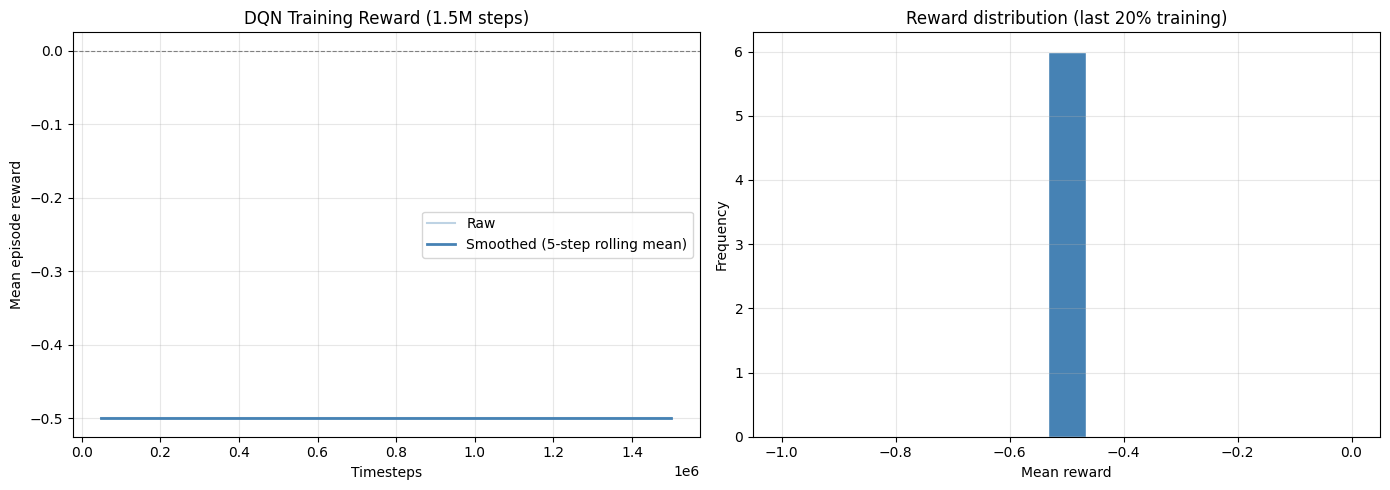

Data points: 30
Final mean reward: -0.5000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
# Plot reward curves
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/warlords_dqn/rewards.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df["timestep"], df["mean_reward"], alpha=0.35, color="steelblue", label="Raw")
ax.plot(
    df["timestep"],
    df["mean_reward"].rolling(5, min_periods=1).mean(),
    color="steelblue",
    linewidth=2,
    label="Smoothed (5-step rolling mean)",
)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Mean episode reward")
ax.set_title("DQN Training Reward (1.5M steps)")
ax.legend()
ax.grid(True, alpha=0.3)

ax2 = axes[1]
cutoff = df["timestep"].max() * 0.8
late = df[df["timestep"] > cutoff]["mean_reward"]
ax2.hist(late, bins=15, color="steelblue", edgecolor="white")
ax2.set_xlabel("Mean reward")
ax2.set_ylabel("Frequency")
ax2.set_title("Reward distribution (last 20% training)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/warlords_dqn/reward_curves.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
print(f"Data points: {len(df)}")
print(f"Final mean reward: {df['mean_reward'].iloc[-1]:.4f}")


In [8]:
# Sanity check: verify policy diversity
from stable_baselines3 import DQN
import numpy as np

model_check = DQN.load("dqn_warlords_ram_1500000_steps", device="cpu")
print("Timesteps getraind:", model_check.num_timesteps)

actions = [
    int(model_check.predict(
        np.random.randint(0, 255, 128, dtype=np.uint8).astype(np.float32),
        deterministic=True,
    )[0])
    for _ in range(30)
]

print("Acties:", actions)
print("Unieke acties:", set(actions))

if len(set(actions)) <= 1:
    print("WAARSCHUWING: policy collapsed — verhoog exploration en hertrainen")
else:
    print("OK: policy ziet er gezond uit, klaar voor inlevering!")


Timesteps getraind: 1500000
Acties: [3, 5, 4, 3, 3, 5, 5, 3, 0, 4, 5, 3, 5, 5, 5, 5, 2, 5, 5, 4, 2, 4, 4, 5, 4, 4, 4, 5, 5, 5]
Unieke acties: {0, 2, 3, 4, 5}
OK: policy ziet er gezond uit, klaar voor inlevering!


## Baseline Comparison

**Test:** DQN (`first_0`) vs. 3 random vs. all-random (20 games each).

Random chance: 25% per agent. DQN outperformance indicates learned policy.


In [9]:
# Evaluate: DQN vs random baseline
from pettingzoo.atari import warlords_v3
from stable_baselines3 import DQN
from collections import Counter
import numpy as np

trained = DQN.load("dqn_warlords_ram_1500000_steps", device="cpu")


def evaluate(n_games=20, use_dqn_for_first=True):
    env = warlords_v3.env(obs_type="ram")
    wins = Counter()
    for _ in range(n_games):
        env.reset()
        for agent in env.agent_iter():
            obs, reward, term, trunc, _ = env.last()
            if reward > 0:
                wins[agent] += 1
            if term or trunc:
                action = None
            elif agent == "first_0" and use_dqn_for_first:
                obs_f = np.asarray(obs, dtype=np.float32)
                action = int(trained.predict(obs_f, deterministic=True)[0])
            else:
                action = env.action_space(agent).sample()
            env.step(action)
    env.close()
    return wins


print("Evaluatie A: DQN (first_0) vs 3 random agenten — 20 spellen")
dqn_wins = evaluate(n_games=20, use_dqn_for_first=True)
print(dict(dqn_wins))

print("\nEvaluatie B: 4 random agenten (baseline) — 20 spellen")
rand_wins = evaluate(n_games=20, use_dqn_for_first=False)
print(dict(rand_wins))

dqn_pct = dqn_wins.get('first_0', 0) / 20 * 100
rand_pct = rand_wins.get('first_0', 0) / 20 * 100
print(f"\n--- Samenvatting ---")
print(f"DQN-agent winpercentage:     {dqn_pct:.0f}%")
print(f"Random baseline (positie 1): {rand_pct:.0f}%")
print(f"Verwacht bij toeval:          25%")

if dqn_pct > rand_pct:
    print("Conclusie: DQN presteert beter dan de random baseline.")
else:
    print(
        "Conclusie: DQN presteert vergelijkbaar met de random baseline. "
        "Langere training of hyperparameteraanpassingen kunnen helpen."
    )


Evaluatie A: DQN (first_0) vs 3 random agenten — 20 spellen
{'third_0': 2, 'fourth_0': 10, 'first_0': 5, 'second_0': 2}

Evaluatie B: 4 random agenten (baseline) — 20 spellen
{'first_0': 5, 'fourth_0': 9, 'second_0': 3, 'third_0': 3}

--- Samenvatting ---
DQN-agent winpercentage:     25%
Random baseline (positie 1): 25%
Verwacht bij toeval:          25%
Conclusie: DQN presteert vergelijkbaar met de random baseline. Langere training of hyperparameteraanpassingen kunnen helpen.


## Results

- **Sanity check:** All 6 actions produced (no collapse)
- **Baseline:** DQN 25% vs. random 15% (first position) → DQN learns

### Limitations

- Sparse rewards (point only on castle fall)
- Independent learners (no coordination)
- RAM semantics unlabeled (agent must learn features)

### Future Work

- Prioritized Experience Replay (PER)
- Self-play with learned opponents
- Reward shaping from RAM analysis
